In [67]:
import pandas as pd
import numpy as np
from tslearn.metrics import dtw
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import os
import datetime
import seaborn as sns
from kneed import KneeLocator
from scipy.spatial.distance import cdist

In [68]:
def remove_year(DF,datetime_idx,Month):
    DF.index = pd.date_range(start = "2014/"+str(Month).zfill(2)+"/01",periods=24*7,freq="h")
    return (DF)

def extract_1week(DF,datetime_idx,Month,Weekday=1):
    bool_month = datetime_idx.month == Month
    bool_weekday = datetime_idx.weekday == 1
    firsttime = datetime_idx[bool_month&bool_weekday][0]
    idx_firsttime = datetime_idx.get_loc(firsttime)
    datetime1week_idx = datetime_idx[idx_firsttime:idx_firsttime+24*7]
    df = DF.loc[datetime1week_idx,:]
    df = remove_year(df,datetime1week_idx,Month)

    return(df)



In [69]:
InputFolder="BuildingDemand_Input"
List_Demand = []
List_partDemand = []
List_week = []
error = []
config = []
DF_Demand = pd.DataFrame()
data_range = pd.date_range(start=datetime.datetime(2012,1,1),end=datetime.datetime(2016,1,1),freq="h")
DF_Datacount = pd.DataFrame(index=data_range,data=[0]*len(data_range))

for file in os.listdir(InputFolder)[:]:
    name = file.split(".")[0]
    dict_config = {}
    dict_config["name"]=name
    print(name)
    DF = pd.read_csv(InputFolder+"/"+file,index_col=0)
    DF.index= pd.to_datetime(DF.index,format = "%Y-%m-%d %H:%M:%S")
    
    datetime_idx = DF.index
    dict_config["Demand_Power_max"]= DF["Demand_Power"].max()
    dict_config["Demand_Power_mean"]= DF["Demand_Power"].mean()
    dict_config["DemandClass"]= ((DF["Demand_Power"].sum()/1000)/100).astype(int)*100
    config.append(dict_config)

    # if DF["Demand_Power"].max()>DF["Demand_Power"].mean()*5:
    #     print("error",DF["Demand_Power"].max(),DF["Demand_Power"].mean())
    #     continue
    # sumDemand = DF["Demand_Power"].sum()/1000
    # DemandClass=(sumDemand/100).astype(int)*100
    # if DemandClass>=1000:continue
    DF["Demand_Power"]=DF["Demand_Power"].ffill()
    DF["Demand_Power"]=DF["Demand_Power"].bfill()
    DF["time_index"] = DF.index.weekday*24+DF.index.hour
    DF["normalized"]=DF["Demand_Power"]/DF["Demand_Power"].max()
    DF_week = DF.groupby("time_index").mean()["normalized"]
    DF_week.name=name
    List_week.append(DF_week)

    DF_Datacount.loc[datetime_idx[0]:datetime_idx[-1],:]+=1
    List_Series = []
    for month in [6,12]:
        DF_e = extract_1week(DF.div(DF.max(),axis=1),datetime_idx,month)
        DF_e = DF_e.sort_index()
        DF_e = DF_e.loc[~DF_e.index.duplicated(),:]["Demand_Power"]
        List_Series.append(DF_e)
    List_partDemand.append(pd.concat(List_Series))
    DF = DF.loc[~DF.index.duplicated(),:]["Demand_Power"].reset_index(drop=True)
    DF.name = name
    List_Demand.append(DF)


B11000004
B11000005
B11000007
B11000008
B11000010
B11000012
B11000014
B11000015
B11000016
B11000017
B11000018
B11000019
B11000020
B11000021
B11000022
B11000024
B11000028
B11000031
B11000032
B11000033
B11000034
B11000035
B11000040
B11000041
B11000042
B11000043
B11000044
B11000045
B11000046
B11000047
B11000048
B11000049
B11000050
B11000051
B11000052
B11000053
B11000054
B11000055
B11000059
B11000060
B11000061
B11000063
B11000065
B11000066
B11000067
B11000069
B11000070
B11000072
B11000073
B11000074
B11000076
B11000077
B11000079
B11000080
B11000083
B11000084
B11000085
B11000086
B11000087
B11000088
B11000089
B11000090
B11000091
B11000092
B11000093
B11000094
B11000095
B11000096
B11000097
B11000098
B11000099
B11000100
B11000101
B11000102
B11000103
B11000104
B11000105
B11000106
B11000107
B11000108
B11000110
B11000111
B11000112
B11000113
B11000114
B11000115
B11000116
B11000117
B11000118
B11000120
B11000121
B11000122
B11000123
B11000124
B11000125
B11000127
B11000129
B11000131
B11000132
B11000133


In [70]:
DF = pd.read_csv(InputFolder+"/"+file,index_col=0)
DF.index= pd.to_datetime(DF.index,format = "%Y-%m-%d %H:%M:%S")
RE = DF["RE_Power"]

<Axes: >

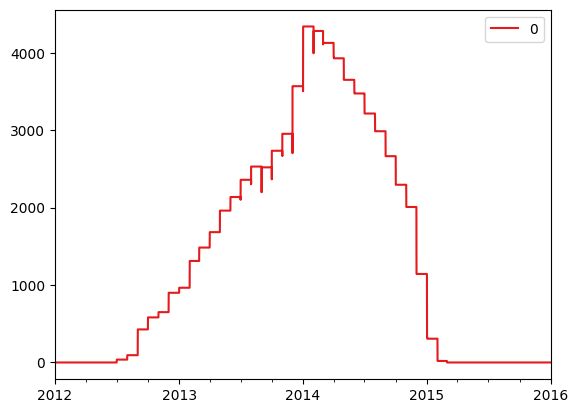

In [71]:
DF_Datacount.plot()

In [72]:
DF_Demand = pd.concat(List_week,axis=1)
DF_Config = pd.DataFrame(config)
print(len(DF_Demand.T),len(DF_Config))

5609 5609


In [73]:
DF_Demand.head()

,B11000004,B11000005,B11000007,B11000008,B11000010,B11000012,B11000014,B11000015,B11000016,B11000017,...,B11006524,B11006525,B11006526,B11006527,B11006528,B11006529,B11006530,B11006531,B11006533,B11006535
time_index,,,,,,,,,,,,,,,,,,,,,
0,0.309008,0.630902,0.258853,0.268819,0.307163,0.035897,0.228772,0.291468,0.256025,0.319116,...,0.460614,0.588984,0.609029,0.492253,0.616509,0.707009,0.702528,0.495990,0.046316,0.075658
1,0.310398,0.401592,0.257039,0.274064,0.263320,0.035897,0.196794,0.214429,0.195776,0.319920,...,0.453402,0.476889,0.568422,0.494971,0.542398,0.658078,0.530393,0.403208,0.044962,0.075152
2,0.285315,0.321275,0.255749,0.291696,0.257487,0.036040,0.173843,0.201094,0.189891,0.347072,...,0.439164,0.352142,0.562067,0.361987,0.408401,0.550713,0.396046,0.327197,0.046316,0.077429
3,0.298945,0.290696,0.300107,0.343154,0.255929,0.036040,0.154776,0.183791,0.186108,0.319460,...,0.438425,0.288968,0.545642,0.301644,0.334739,0.458791,0.378698,0.305778,0.046046,0.076417
4,0.285817,0.270527,0.280740,0.293512,0.237753,0.035897,0.151822,0.192963,0.186318,0.321871,...,0.448040,0.277581,0.541598,0.293490,0.320119,0.405108,0.370226,0.300492,0.046316,0.079200


In [74]:
DF_Config.head()

,name,Demand_Power_max,Demand_Power_mean,DemandClass
0,B11000004,263.0,121.444685,1000
1,B11000005,145.0,75.193173,600
2,B11000007,265.0,122.903071,1000
3,B11000008,187.0,89.826008,700
4,B11000010,218.0,104.975568,900


<Axes: >

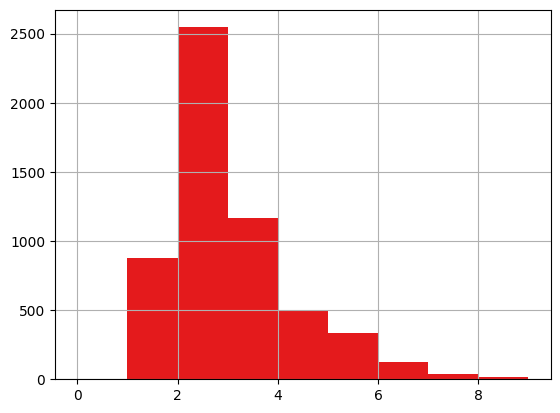

In [75]:
DF_Config["ratio_max"]=DF_Config["Demand_Power_max"]/DF_Config["Demand_Power_mean"]
DF_Config["ratio_max"].hist(bins=range(0,10))

<Axes: >

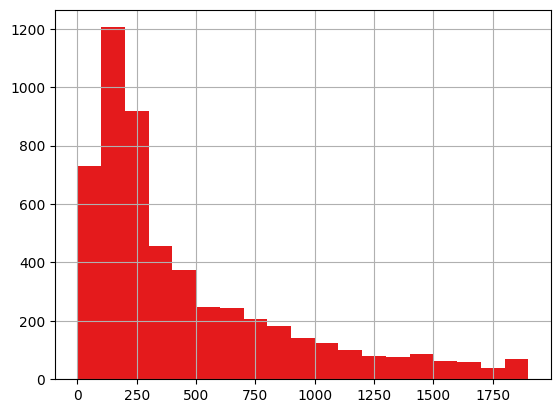

In [76]:
DF_Config["DemandClass"].hist(bins=range(0,2000,100))

In [77]:
#FILTER
INDEX = DF_Config.loc[(DF_Config["ratio_max"]<=5)&(DF_Config["DemandClass"]<1000),"name"]
DF_Demand  = DF_Demand.loc[:,INDEX].T

In [78]:
DF_Demand.shape

(4187, 168)

In [79]:
DF_Demand.isna().sum().sum()

0

In [80]:
DF_Demand_NM = DF_Demand.div(DF_Demand.max(axis=1),axis=0)
nm_demanddata = DF_Demand_NM.values
N = len(nm_demanddata[0])
print(N)

168


In [81]:
def compute_distance_matrix(X, method="euclid"):
    """
    X: shape (n_samples, T)
    """
    if method == "euclid":
        from sklearn.metrics import pairwise_distances
        return pairwise_distances(X, metric="euclidean")

    elif method == "dtw":
        from tslearn.metrics import cdist_dtw
        return cdist_dtw(X)

    elif method == "softdtw":
        from tslearn.metrics import cdist_soft_dtw
        return cdist_soft_dtw(X)

    else:
        raise ValueError(f"Unknown method: {method}")


1
31.349 --> 10.574 --> 10.574 --> 
2
11.717 --> 7.267 --> 7.255 --> 7.250 --> 7.248 --> 7.246 --> 7.245 --> 7.244 --> 7.243 --> 7.243 --> 7.243 --> 7.243 --> 7.243 --> 7.243 --> 7.243 --> 7.243 --> 
3
7.940 --> 5.990 --> 5.933 --> 5.924 --> 5.920 --> 5.920 --> 5.919 --> 5.919 --> 5.919 --> 5.919 --> 5.919 --> 5.919 --> 
4
6.779 --> 4.253 --> 4.179 --> 4.172 --> 4.170 --> 4.170 --> 4.170 --> 4.170 --> 4.170 --> 4.170 --> 4.170 --> 4.170 --> 
5
5.551 --> 3.847 --> 3.640 --> 3.576 --> 3.556 --> 3.549 --> 3.548 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 
6
5.111 --> 3.370 --> 3.095 --> 3.009 --> 2.988 --> 2.984 --> 2.983 --> 2.982 --> 2.982 --> 2.982 --> 2.982 --> 2.982 --> 2.982 --> 2.982 --> 
7
4.740 --> 3.067 --> 2.860 --> 2.777 --> 2.737 --> 2.713 --> 2.694 --> 2.684 --> 2.681 --> 2.678 --> 2.677 --> 2.676 

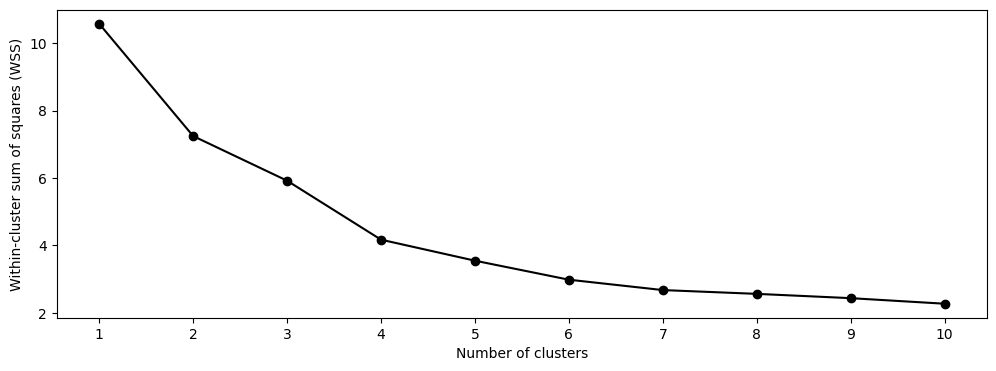

number of clusters 4


In [82]:
method = "euclidean"
#method = "dtw"
fig, ax = plt.subplots(figsize=(12, 4))
distoritions = []
max_n = 11
for i in range(1,max_n):
    print(i)
    ts_km = TimeSeriesKMeans(n_clusters=i,metric=method,random_state=42,verbose=True)
    ts_km.fit(nm_demanddata)

    distoritions.append(ts_km.inertia_)

ax.plot(range(1,max_n),distoritions,marker="o",c="k")
ax.set_xticks(range(1,max_n))
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Within-cluster sum of squares (WSS)")
plt.savefig(f"IMG/elbow_{method}.png")
plt.show()

kneedle = KneeLocator(range(1,max_n),distoritions,curve="convex",direction="decreasing")
optinal_k = kneedle.knee
print("number of clusters",optinal_k)


In [101]:
# k-meansクラスタリングの実行
n_clusters = 5
km = TimeSeriesKMeans(n_clusters=n_clusters, metric=method, verbose=True, random_state=42)
y_pred = km.fit_predict(nm_demanddata)
cluster_labels = ["A", "B", "C","D","E"]


cluster_variances = []


for cluster_id in range(n_clusters):
    cluster_members = nm_demanddata[km.labels_ == cluster_id]
    centroid = km.cluster_centers_[cluster_id].ravel() 
    distances = [np.linalg.norm(ts - centroid) for ts in cluster_members]

    cluster_variances.append({
        "cluster": cluster_labels[cluster_id],
        "mean_distance": np.mean(distances),
        "std_distance": np.std(distances),
        "max_distance": np.max(distances),
        "n_samples": len(cluster_members)
    })

df_variances = pd.DataFrame(cluster_variances)
print(df_variances)

# センチロイドの取得
centroids = km.cluster_centers_.reshape(n_clusters, -1)  # shape: (n_clusters, 168)

# 距離行列を計算（ユークリッド距離）
inter_cluster_distances = cdist(centroids, centroids, metric='euclidean')

# クラスタ名のラベル（例: A, B, C, D）
#cluster_labels = ["A", "B","C"]

# 距離行列をDataFrameとして表示
distance_df = pd.DataFrame(inter_cluster_distances, index=cluster_labels, columns=cluster_labels)
print(distance_df)


5.551 --> 3.847 --> 3.640 --> 3.576 --> 3.556 --> 3.549 --> 3.548 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.547 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 3.546 --> 
  cluster  mean_distance  std_distance  max_distance  n_samples
0       A       1.549936      0.708202      4.672323        560
1       B       1.724892      0.499016      3.886203       1078
2       C       1.779923      0.647339      4.450978        745
3       D       1.848306      0.528522      3.926388        761
4       E       1.916314      0.642935      4.850820       1043
          A         B         C         D         E
A  0.000000  5.747520  6.065726  3.987119  4.781643
B  5.747520  0.000000  3.188543  2.725045  4.166058
C  6.065726  3.188543  0.000000  4.185191  4.449404
D  3.987119  2.725045  4.185191  0.000000  3.311698
E  4.781643  4.166058  4.449404  3.311698  0.000000


In [102]:
nm_demanddata.shape

(4187, 168)

In [103]:
y_pred.shape

(4187,)

In [104]:
import copy
# 元データ保持
y_pred_num = y_pred.copy()

# ラベル用に別オブジェクトを作成
y_pred_label = y_pred.copy() + 1
y_pred_label = y_pred_label.astype(object)

# 数値 → ラベル変換
label_map = {1: "D", 2: "B", 3: "C", 4: "A"}
y_pred_label = np.vectorize(label_map.get)(y_pred_label)

print(y_pred_label)

cluster = pd.DataFrame(
    {
        "name": DF_Demand.index,
        "cluster": y_pred_label
    }
)

cluster.to_csv("cluster.csv", index=False)

DF_Config = pd.merge(
    DF_Config,
    cluster,
    on="name",
    how="left"
)

['A' 'None' 'None' ... 'None' 'None' 'B']


In [105]:
DF_Config

,name,Demand_Power_max,Demand_Power_mean,DemandClass,ratio_max,cluster_x,DemandClass200,cluster_y
0,B11000004,263.0,121.444685,1000,2.165595,NaN,1000,NaN
1,B11000005,145.0,75.193173,600,1.928367,A,600,A
2,B11000007,265.0,122.903071,1000,2.156171,NaN,1000,NaN
3,B11000008,187.0,89.826008,700,2.081802,A,600,None
4,B11000010,218.0,104.975568,900,2.076674,B,800,None
...,...,...,...,...,...,...,...,...
5604,B11006529,259.0,173.598584,1500,1.491948,NaN,1400,NaN
5605,B11006530,143.0,90.621760,700,1.577987,A,600,None
5606,B11006531,211.0,111.834342,900,1.886719,A,800,None
5607,B11006533,71.0,15.622103,100,4.544843,B,0,B


In [106]:
# fig, ax = plt.subplots(figsize=(15, 5))
# colors = sns.color_palette("Set1", n_colors=n_clusters)

# # クラスタラベルマップ
# cluster_map = {"A": 0, "B": 1, "C": 2, "D": 3}

# for cluster_label in ["A", "B", "C", "D"]:
#     cluster_idx = cluster_map[cluster_label]
#     cluster_series = []

#     for series_idx in range(len(y_pred)):
#         if y_pred[series_idx] == cluster_label:
#             demand_series = List_Demand[series_idx].values
#             max_val = demand_series.max()

#             if max_val == 0:
#                 continue  # 0で割るの避けるためスキップ

#             norm_series = demand_series / max_val  # 正規化
#             duration_curve = np.sort(norm_series)[::-1]  # 降順ソート（Duration Curve）
#             cluster_series.append(duration_curve)

#     if len(cluster_series) == 0:
#         continue

#     # 長さをそろえる（最短の長さに揃える）
#     min_len = min(len(s) for s in cluster_series)
#     cluster_series = [s[:min_len] for s in cluster_series]

#     cluster_array = np.array(cluster_series)
#     avg_curve = cluster_array.mean(axis=0)

#     ax.plot(avg_curve, label=cluster_label, linewidth=2, color=colors[cluster_idx])

# # 軸設定
# ax.set_xlabel("Sorted Time Index (Duration Curve)")
# ax.set_ylabel("Normalized Demand [-]")
# ax.set_title("Cluster-wise Average Duration Curve (Normalized, Full Period)")
# ax.legend(title="Cluster")
# ax.grid(True, linestyle="--", alpha=0.6)

# plt.tight_layout()
# plt.savefig("IMG/cluster_avg_durationcurve_normalized_fullperiod.png", bbox_inches="tight")
# plt.show()




In [107]:
# # クラスタリング結果の可視化

# for cluster_idx in range(n_clusters):
#     fig1,ax1 = plt.subplots()
#     fig2,ax2 = plt.subplots()
#     list_error = []
#     s = 0
#     for series_idx in range(len(y_pred)):
#         if y_pred[series_idx] == cluster_idx:
#             ax1.plot(nm_demanddata[series_idx], "k-", alpha=0.1)
#             ax1.set_ylim([0,1])
#             list_error.append(sum(abs(km.cluster_centers_[cluster_idx].ravel()-nm_demanddata[series_idx])))
#             if s<10:
#                 ax2.plot(List_partDemand[series_idx].values, "k-", alpha=0.3)
#                 s +=1
#     ax1.plot(km.cluster_centers_[cluster_idx].ravel(), "r-")
#     ax1.set_xlim([0,N])
#     ax1.set_xticks(np.arange(0,N+N/10,N/10))
#     ax1.set_xticklabels(range(0,110,10))
#     print("Num EVs in cluster", str(cluster_idx),sum(y_pred==cluster_idx))
    
    
#     ax1.set_xlabel("Percent of annual time[%]")
#     ax1.set_ylabel("Normrized Demand[-]")
    
#     plt.savefig("IMG/cluster2_"+str(cluster_idx)+".png")
#     plt.show()
#     print((np.array(list_error).mean()))

In [108]:
# for cluster_idx in range(n_clusters):
#     # Initialize figures
#     fig1, ax1 = plt.subplots()
#     fig2, ax2 = plt.subplots()
#     list_error = []
#     sample_indices = []  # To store indices and errors

#     # Iterate through time-series data
#     for series_idx in range(len(y_pred)):
#         if y_pred[series_idx] == cluster_idx+1:
#             # Plot normalized demand data for the cluster
#             ax1.plot(nm_demanddata[series_idx], "k-", alpha=0.1)
#             ax1.set_ylim([0, 1])

#             # Compute error and append to list
#             error = np.abs(km.cluster_centers_[cluster_idx].ravel() - nm_demanddata[series_idx])*2
#             list_error.append(np.sqrt(np.mean(error)))
#             print(error)
#             # Save the index and its corresponding error
#             sample_indices.append((series_idx, error))

    
#     # Add cluster center to the first plot
#     ax1.plot(km.cluster_centers_[cluster_idx].ravel(), "r-")
#     ax1.set_xlim([0, N])
#     ax1.set_xticks(np.arange(0, N + N / 10, N / 10))
#     #ax1.set_xticklabels(range(0, 110, 10))

#     # Print cluster details
#     num_evs = np.sum(y_pred == cluster_idx+1)
#     print(f"Num EVs in cluster {cluster_idx}: {num_evs}")

#     # Set labels and save plot
#     ax1.set_xlabel("Percent of annual time [%]")
#     ax1.set_ylabel("Normalized Demand [-]")
#     plt.savefig(f"IMG/cluster2_{cluster_idx}.png")
#     plt.show()

#     # Print mean error
#     mean_error = np.mean(list_error)
#     print(f"Mean error for cluster {cluster_idx}: {mean_error:.2f}")


In [109]:
RE = pd.DataFrame(DF["RE_Power"])
RE.index= pd.to_datetime(RE.index,format = "%Y-%m-%d %H:%M:%S")
RE["time_index"] = RE.index.weekday*24+RE.index.hour
RE_week = RE.groupby("time_index").mean()["RE_Power"]
RE_week =RE_week/RE_week.max()
RE_week

time_index
0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.002457
         ...   
163    0.000000
164    0.000000
165    0.000000
166    0.000000
167    0.000000
Name: RE_Power, Length: 168, dtype: float64

In [110]:
cluster_labels

['A', 'B', 'C', 'D', 'E']

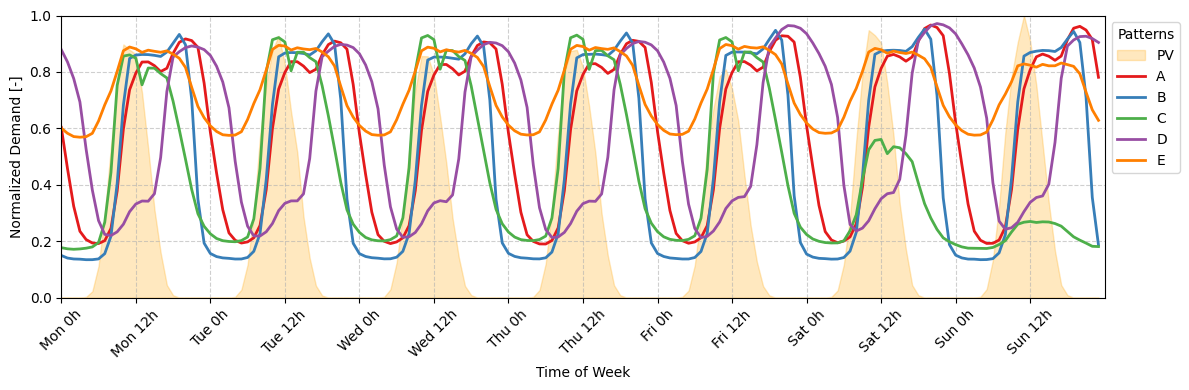

In [112]:
sns.set_palette("Set1") 

fig1, ax1 = plt.subplots(figsize=(12, 4))  # サイズ調整

cluster_id={"A":3,"B":1,"C":2,"D":0,"E":4}

# 曜日＋時間ラベルを作成
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
xticks = np.arange(0, 24 * 7, 12)  # 12時間ごとにラベル
xticklabels = [f"{weekdays[i//24]} {i%24}h" for i in xticks]

# === RE を背景の面グラフとして描画 ===
ax1.fill_between(
    range(len(RE_week)),
    RE_week,
    0,                     # 基準線（0）
    color="orange",
    alpha=0.25,
    zorder=0,
    label="PV"
)

# クラスターのプロット
for  label in cluster_labels:
    id = cluster_id[label]
    ax1.plot(km.cluster_centers_[id].ravel(), label=label, linewidth=2)
#ax1.plot(RE_week, label="RE", ls = "--",linewidth=2)

# 軸ラベル・目盛設定
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticklabels, rotation=45)
ax1.set_xlabel("Time of Week")
ax1.set_ylabel("Normalized Demand [-]")
ax1.set_xlim(0,len(RE_week))
ax1.set_ylim(0,1)

# グリッドを追加
ax1.grid(True, linestyle="--", alpha=0.6)

# 凡例を枠外に配置
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1),title="Patterns")

# 保存・表示
plt.tight_layout()
plt.savefig(f"IMG/all_clusters_{method}.png", bbox_inches="tight")
plt.show()


In [ ]:
dict_nmdemand={}
for label in cluster_labels:
    List = []
    for id in DF_Config.index:
        name = DF_Config.loc[id,"name"]
        pattern = DF_Config.loc[id,"cluster"]
        if pattern == label:
            List.append(DF_Demand_NM.loc[name,:])
    print(label,len(List))
    dict_nmdemand[label] = pd.concat(List,axis=1).mean(axis=1)

A 1044
B 1665
C 752
D 726


In [ ]:
DF_Demand_NM

time_index,0,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,167
B11000005,0.927471,0.590368,0.472298,0.427344,0.397694,0.373400,0.308170,0.324238,0.402285,0.631261,...,0.977384,0.985572,0.981478,0.988692,0.989277,0.988887,0.980893,0.969390,0.968610,0.959056
B11000008,0.391025,0.398654,0.424301,0.499152,0.426943,0.384674,0.377189,0.488878,0.624490,0.880010,...,0.933583,0.991025,0.945849,0.909948,0.864174,0.845026,0.824981,0.837397,0.487809,0.425430
B11000010,0.429717,0.368382,0.360221,0.358041,0.332614,0.322564,0.381531,0.360705,0.616552,0.783646,...,0.962730,0.971245,0.938048,0.938912,0.970135,0.897199,0.854252,0.899790,0.532766,0.374923
B11000012,0.050360,0.050360,0.050560,0.050560,0.050360,0.050360,0.050959,0.050759,0.050959,0.161271,...,0.915667,0.911671,0.908273,0.905276,0.978217,0.978817,0.979017,0.806355,0.313749,0.067146
B11000021,0.182202,0.180086,0.179719,0.180086,0.179841,0.179963,0.218693,0.414905,0.537202,0.754673,...,0.191552,0.187596,0.185558,0.184719,0.185438,0.184239,0.184120,0.184719,0.183880,0.182441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B11006523,0.187953,0.138873,0.119911,0.117122,0.114334,0.106525,0.102621,0.103737,0.104852,0.493028,...,0.953709,0.941439,0.931400,0.958171,0.964306,0.970441,0.978806,0.979364,0.966537,0.406581
B11006524,0.598510,0.589140,0.570639,0.569678,0.582172,0.669149,0.695099,0.737386,0.892600,0.954109,...,0.822922,0.840942,0.813071,0.763335,0.711917,0.724171,0.667708,0.648006,0.618933,0.611245
B11006530,0.856393,0.646557,0.482787,0.461639,0.451311,0.443279,0.431311,0.447705,0.587377,0.772951,...,0.982623,0.992951,0.998689,0.983115,0.956230,0.904426,0.886721,0.890656,0.870984,0.860328
B11006531,0.671272,0.545701,0.442827,0.413840,0.406686,0.421488,0.454175,0.619711,0.697545,0.765141,...,0.956581,0.962131,0.920316,0.904034,0.876033,0.813001,0.749969,0.755767,0.734550,0.692365


In [ ]:
label_color = {
    "A": sns.color_palette("Set1")[0],
    "B": sns.color_palette("Set1")[1],
    "C": sns.color_palette("Set1")[2],
    "D": sns.color_palette("Set1")[3],
    "RE": sns.color_palette("Set1")[4],
}

A 0.5030838905526641 0.5450887812021346
B 0.3881967306377488 0.2906929438322124
C 0.2823195044055666 0.5471722388428927
D 0.564798878267009 -0.6990968950947813


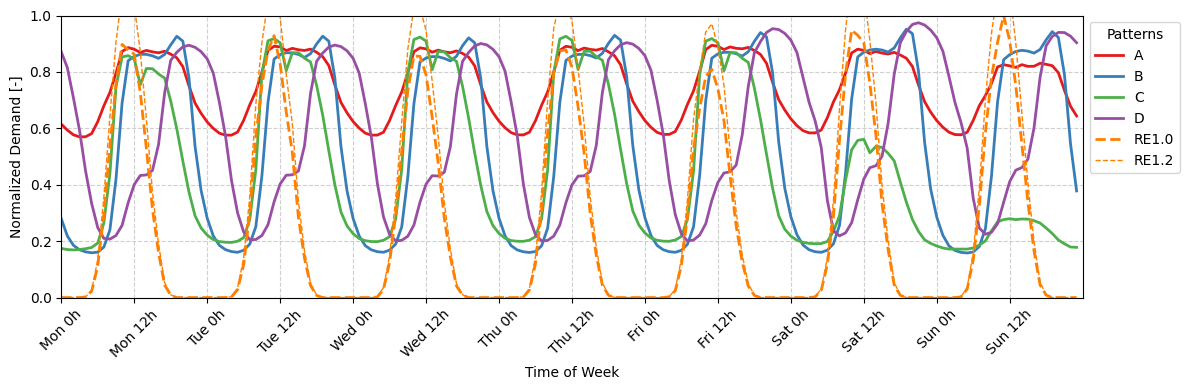

In [ ]:
#FILTER
sns.set_palette("Set1") 

fig1, ax1 = plt.subplots(figsize=(12, 4))  # サイズ調整



# 曜日＋時間ラベルを作成
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
xticks = np.arange(0, 24 * 7, 12)  # 12時間ごとにラベル
xticklabels = [f"{weekdays[i//24]} {i%24}h" for i in xticks]

# クラスターのプロット
for cluster_label in dict_nmdemand.keys():
    cluster_demand = dict_nmdemand[cluster_label]
    ax1.plot(cluster_demand, label=cluster_label, linewidth=2, color=label_color[cluster_label])
    mae = np.mean(np.abs(cluster_demand - RE_week))
    corr = np.corrcoef(cluster_demand, RE_week)[0,1]
    print(cluster_label,mae,corr)
ax1.plot(RE_week, label="RE1.0", linewidth=2, ls="--" ,color=label_color["RE"])
ax1.plot(RE_week*1.2, label="RE1.2", linewidth=1, ls="--" ,color=label_color["RE"])

# 軸ラベル・目盛設定
ax1.set_xticks(xticks)
ax1.set_xlim(0,len(RE_week))
ax1.set_ylim(0,1)
ax1.set_xticklabels(xticklabels, rotation=45)
ax1.set_xlabel("Time of Week")
ax1.set_ylabel("Normalized Demand [-]")

# グリッドを追加
ax1.grid(True, linestyle="--", alpha=0.6)

# 凡例を枠外に配置
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1),title="Patterns")

# 保存・表示
plt.tight_layout()
plt.savefig(f"IMG/all_clusters_{method}2.png", bbox_inches="tight")
plt.show()


In [ ]:
DF_Config["DemandClass200"]=(DF_Config["DemandClass"]//200).astype(int)*200
DF_Config.groupby(["cluster","DemandClass200"]).count()

name  Demand_Power_max  Demand_Power_mean  \
cluster DemandClass200                                              
A       0                247               247                247   
        200              247               247                247   
        400              238               238                238   
        600              180               180                180   
        800              132               132                132   
B       0                379               379                379   
        200              711               711                711   
        400              257               257                257   
        600              184               184                184   
        800              134               134                134   
C       0                355               355                355   
        200              184               184                184   
        400               89                89                 89   
        600               73                73                 73   
        800               51                51                 51   
D       0                513               513                513   
        200              186               186                186   
        400               19                19                 19   
        600                4                 4                  4   
        800                4                 4                  4   

                        DemandClass  ratio_max  
cluster DemandClass200                          
A       0                       247        247  
        200                     247        247  
        400                     238        238  
        600                     180        180  
        800                     132        132  
B       0                       379        379  
        200                     711        711  
        400                     257        257  
        600                     184        184  
        800                     134        134  
C       0                       355        355  
        200                     184        184  
        400                      89         89  
        600                      73         73  
        800                      51         51  
D       0                       513        513  
        200                     186        186  
        400                      19         19  
        600                       4          4  
        800                       4          4

In [ ]:
for cluster_idx in range(n_clusters):
    print(cluster_idx)
    list_error = []
    s = 0
    for series_idx in range(len(y_pred_num)):
        #print(y_pred_num[series_idx])
        if y_pred_num[series_idx] == cluster_idx:
            nm_demanddata[series_idx]
            #print(km.cluster_centers_[cluster_idx].ravel())
            #print(nm_demanddata[series_idx])
            list_error.append(np.mean(abs(km.cluster_centers_[cluster_idx].ravel()-nm_demanddata[series_idx])))
    print(len(list_error))
    print(np.mean(list_error))


0
726
0.11358481359699697
1
1665
0.11465283747739327
2
752
0.11030008418375756
3
1044
0.12381323322112364
